### Etap 3

Ostatnia część projektu związana jest z opracowaniem modelu regresji (2,5 pkt.), poprzez
zastosowanie poznanych na wykładzie i ćwiczeniach laboratoryjnych metodach doboru cech
(2,5 pkt.) i regularyzacji (2,5 pkt.) oraz opracowanie raportu opisującego przeprowadzone prace,
jak i wyciągnięte wnioski z otrzymanych wyników/zależności (2,5 pkt.).

In [116]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

Wczytanie zbioru danych

In [117]:
df = pd.read_csv('data/df_merged_without_outliers.csv')

### Transformacje zmiennych, aby ich rozkład był bardziej podobny do normalnego

Lista atrybutów o rozkładzie prawo skośnym:

In [118]:
right_skewed = np.array(['TotalPop', 'Hispanic', 'Black', 'Native', 'Asian', 'Pacific', 'Transit', 'Walk', 'OtherTransp', 'WorkAtHome', 'PublicWork', 'SelfEmployed', 'FamilyWork', 'Average_House_Price'], dtype=object)

Lista atrybutów o rozkładzie lewo skośnym:

In [119]:
left_skewed = np.array(['White', 'Drive', 'PrivateWork'], dtype=object)

Wybranie odpowiedniej podstawy logarytmu z przedziału [1.5, 2.0, 2.5, ..., 10.0] przy użyciu testu statystycznego Shapiro-Wilk. Jeżeli logarytmowanie nie pomoże, histogram dla logarytmowanych warotści nie będzie wyświetlany.

<Figure size 1000x2500 with 0 Axes>

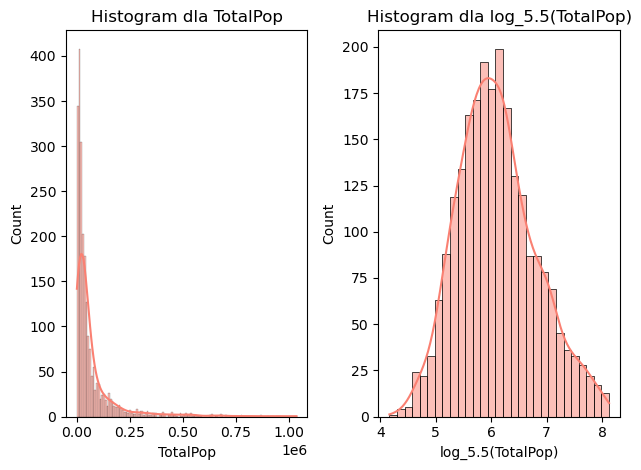

<Figure size 1000x2500 with 0 Axes>

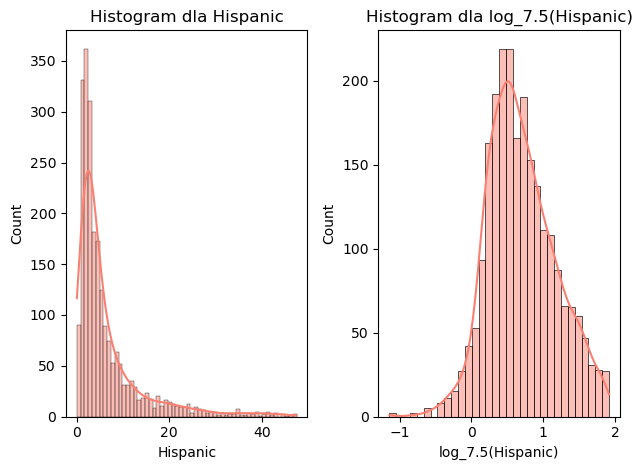

<Figure size 1000x2500 with 0 Axes>

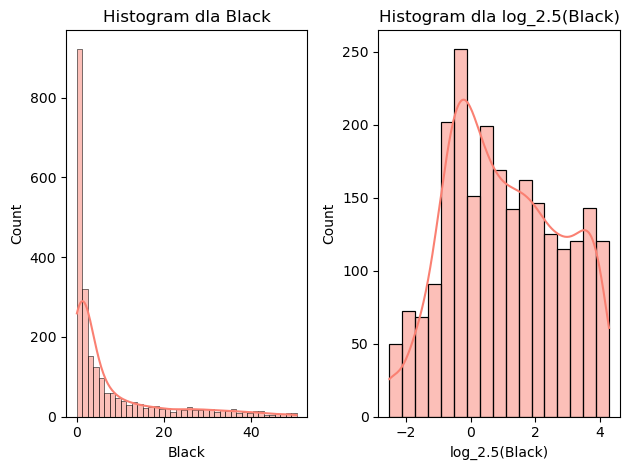

<Figure size 1000x2500 with 0 Axes>

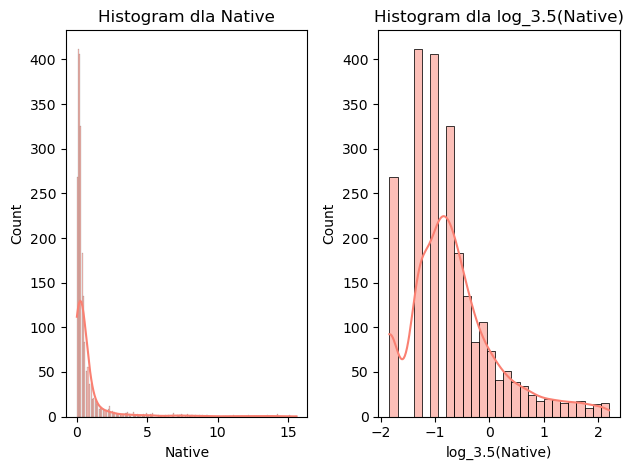

<Figure size 1000x2500 with 0 Axes>

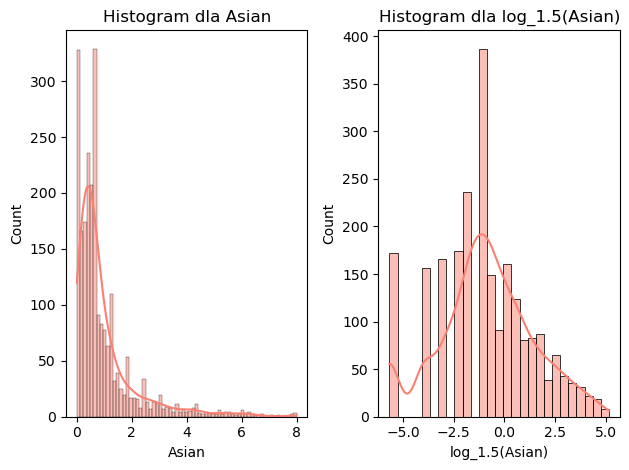

<Figure size 1000x2500 with 0 Axes>

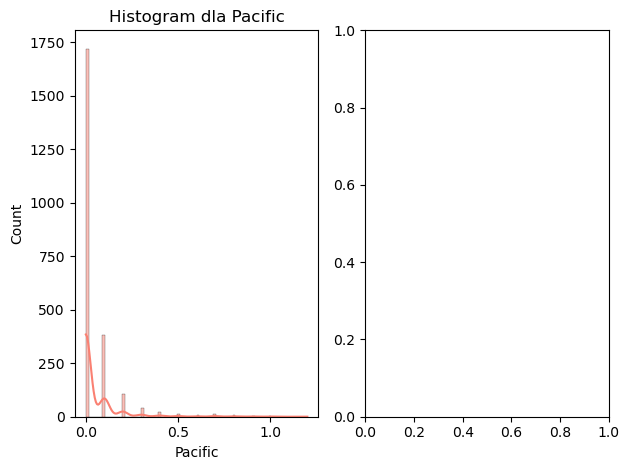

<Figure size 1000x2500 with 0 Axes>

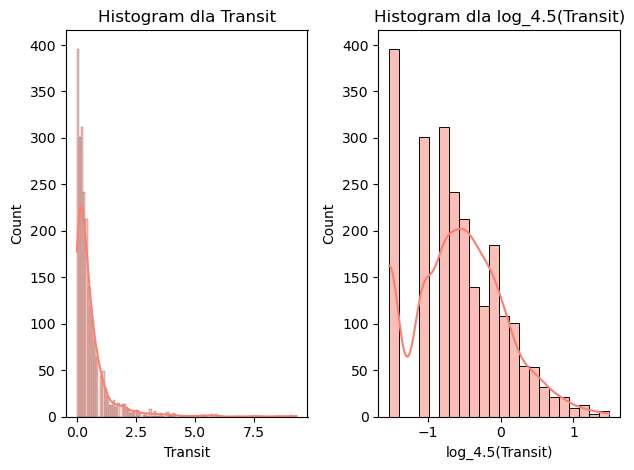

<Figure size 1000x2500 with 0 Axes>

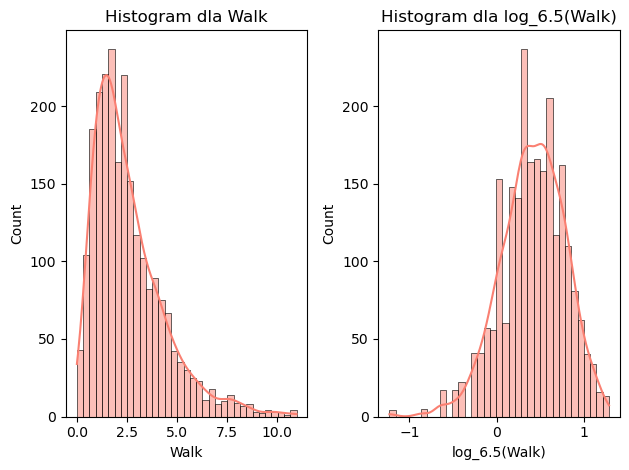

<Figure size 1000x2500 with 0 Axes>

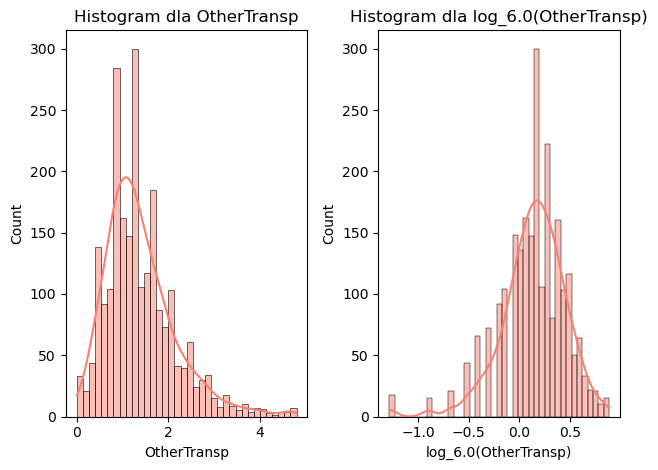

<Figure size 1000x2500 with 0 Axes>

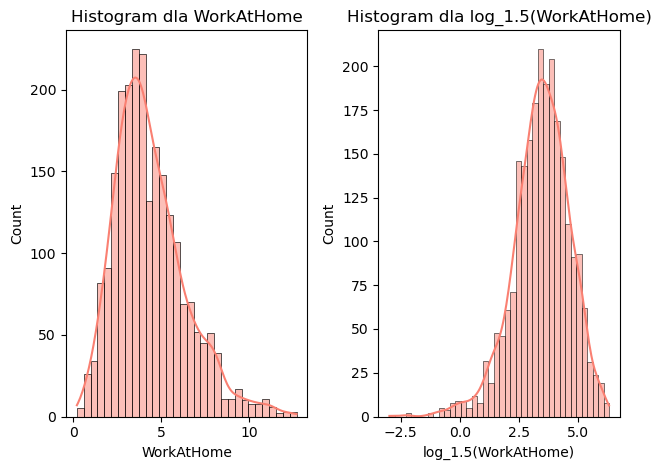

<Figure size 1000x2500 with 0 Axes>

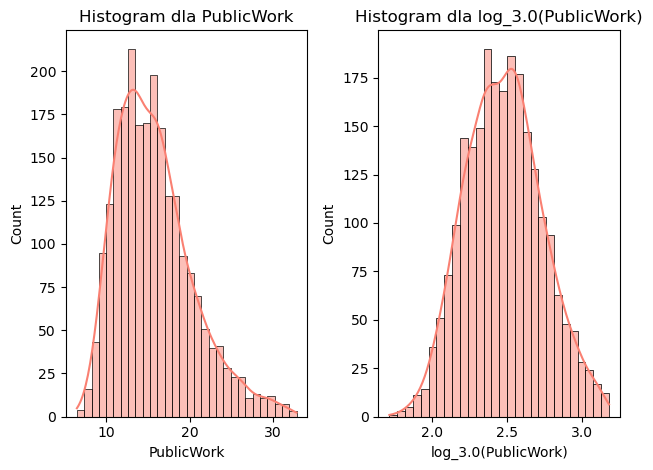

<Figure size 1000x2500 with 0 Axes>

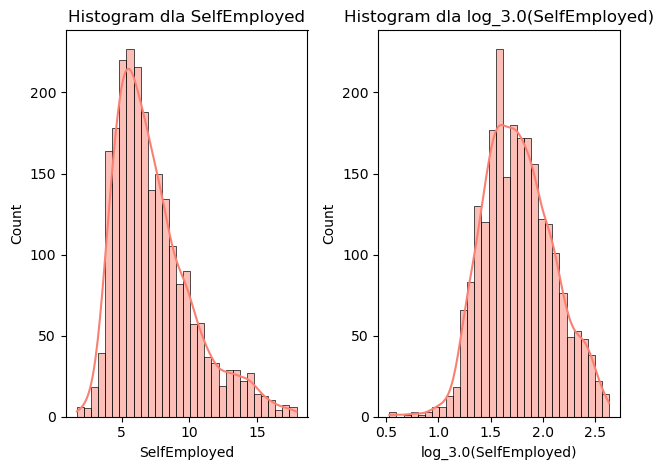

<Figure size 1000x2500 with 0 Axes>

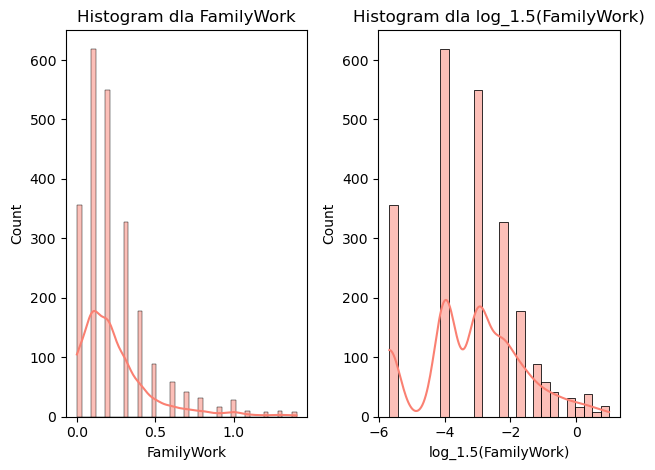

<Figure size 1000x2500 with 0 Axes>

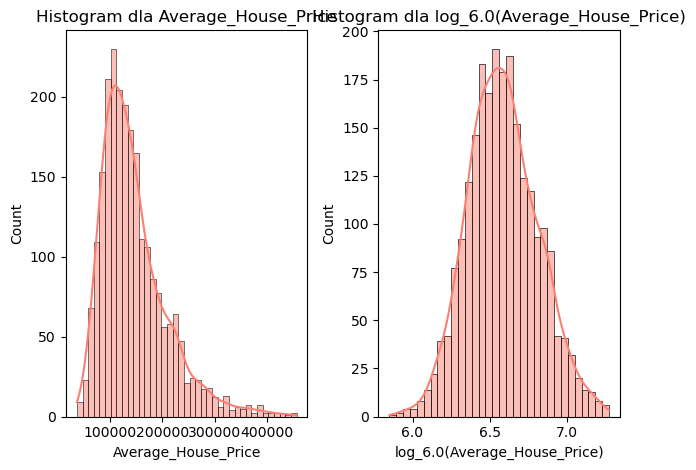

In [120]:
from scripts.right_skewed_to_normal import to_normal

for attr in right_skewed:
    df = to_normal(df, attr)

Dla wszystkich atrybutów poza `Pacifi` logarytmowanie pomogło uzyskać rozkład bardziej zbliżony do normalnego.

Podnoszenie do potęgi, aby z rozkładu prawoskośnego przejsć na bardziej przypominający normalny. Wybranie odpowiedniego wykładnika z przedziału [1.5, 2.0, 2.5, ..., 10.0] przy użyciu testu statystycznego Shapiro-Wilk. Jeżeli podnoszenie do potęgi nie pomoże, histogram dla logarytmowanych warotści nie będzie wyświetlany.

<Figure size 1000x2500 with 0 Axes>

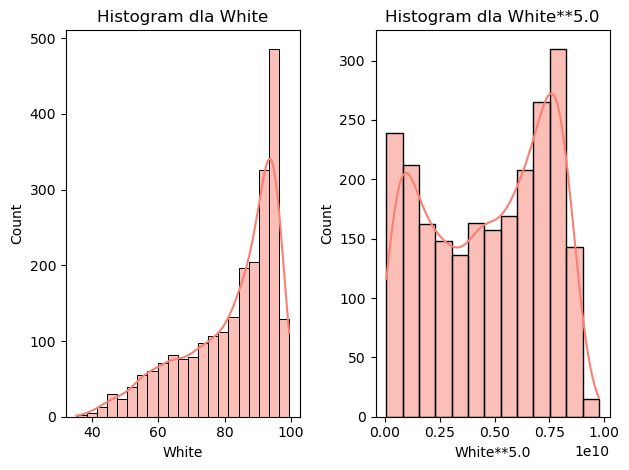

<Figure size 1000x2500 with 0 Axes>

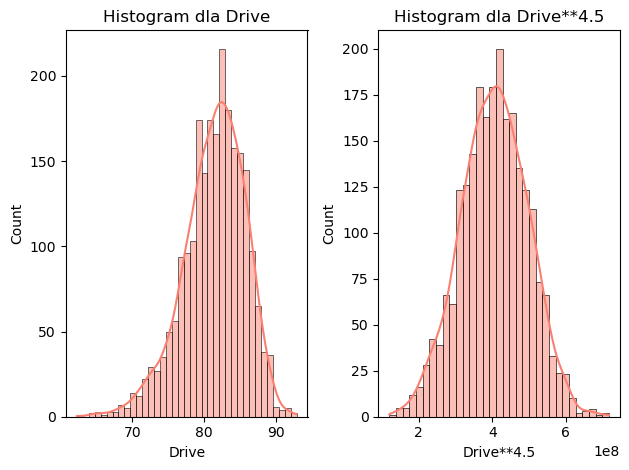

<Figure size 1000x2500 with 0 Axes>

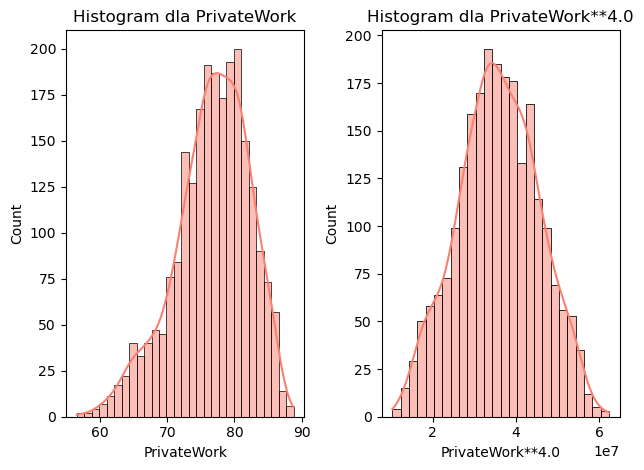

In [121]:
from scripts.left_skewed_to_normal import to_normal

for attr in left_skewed:
    df = to_normal(df, attr)

Dla wszystkich atrybutów z rozkładem prawoskośnym potęgowanie pomogło uzyskać rozkład bardziej normalny, jednakże dla atrybutu `White` zmieniło rokzład z jednomodalnego na dwumodalny

### Macierz korelacji, po dodaniu nowych danych

Spojrzeć na public Work i Private Work, aby usunąć, któryś z tych i podobnie z White i Black

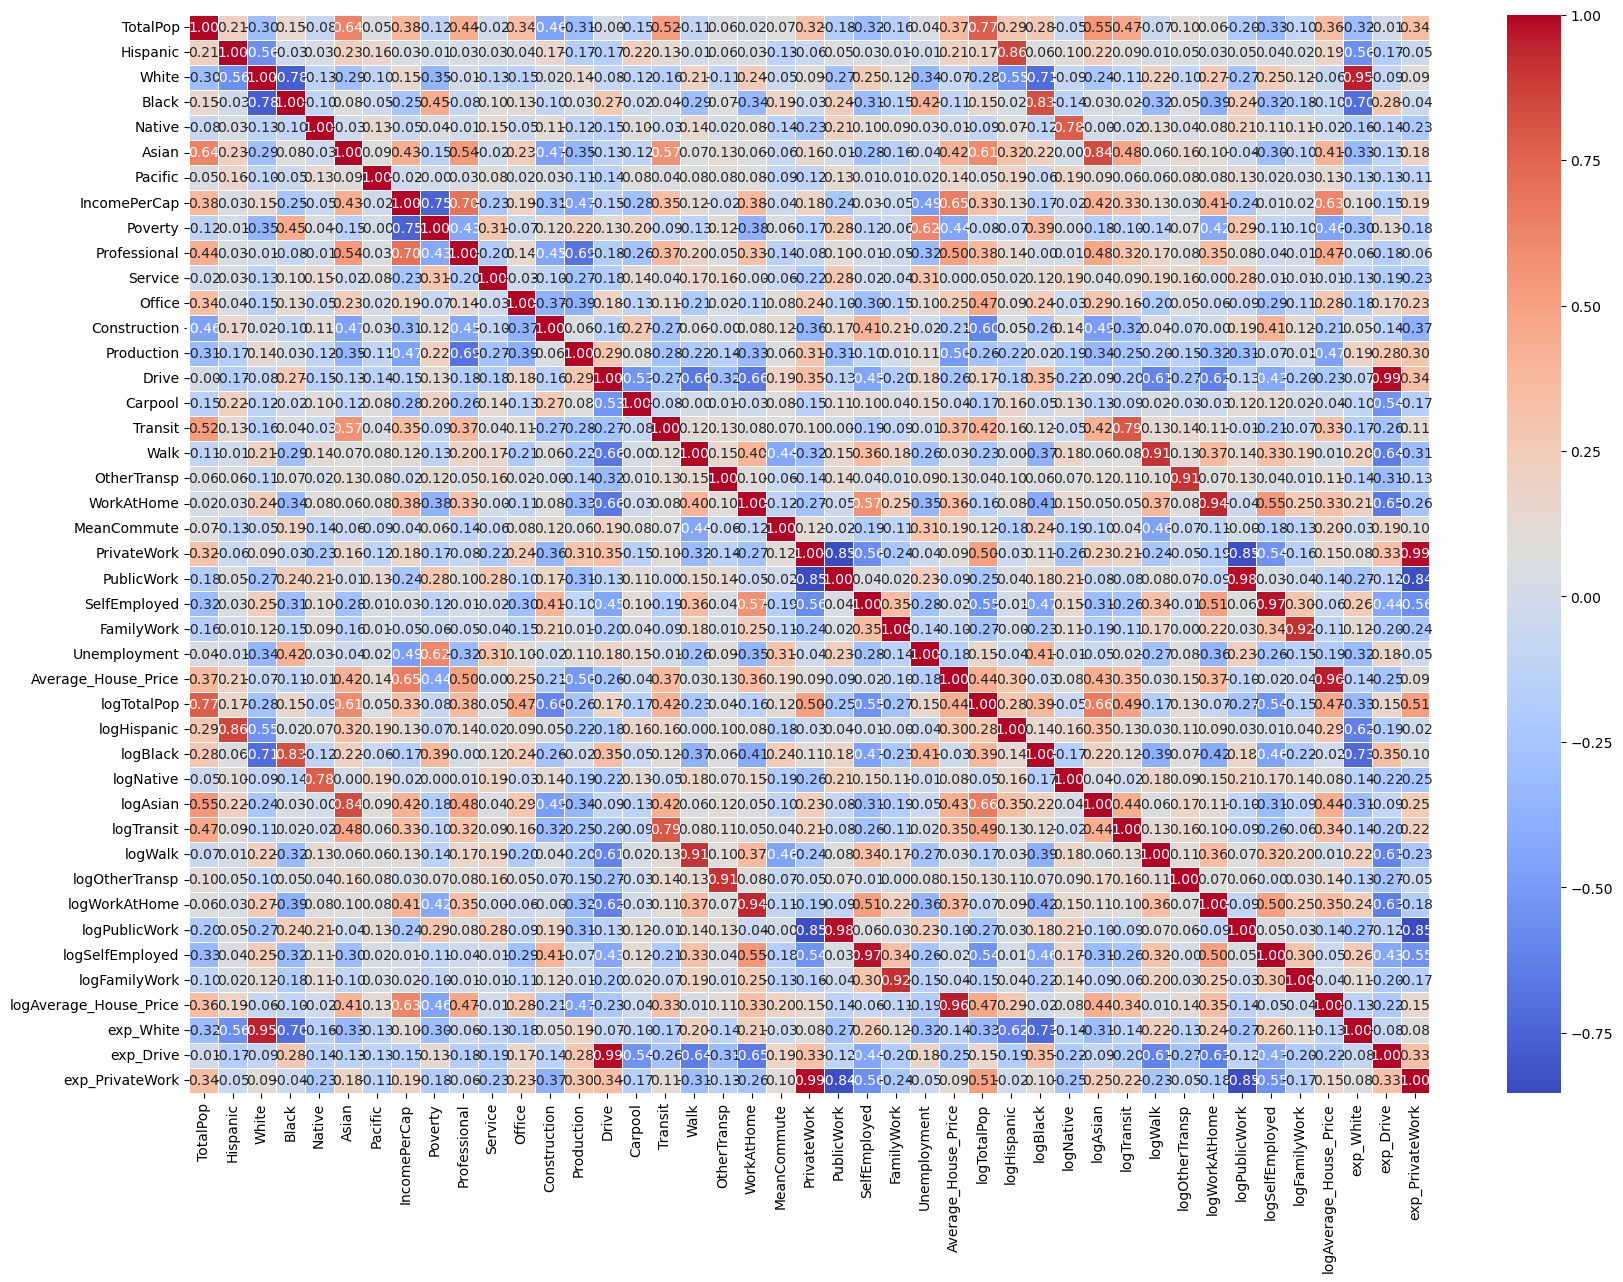

In [122]:
correlation_matrix = df.iloc[:,3:].corr()

plt.figure(figsize=(20, 14))
heatmap = sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm',fmt=".2f", linewidths=0.5)

Każda z dodanych nowo atrybutów, po przetranformowaniu cech ma wysoką korelację z atrybutem przed transformacją, więc należy usunąć któreś z tych par, także pozbędziemy się danych, które po transformacji mają rozkład bardziej zgodny z normalnym

### Sprawdzenie, czy korelacja uległa poprawie przy transformacji

In [123]:
from scripts.check_corr import check_corr

check_corr(df, 3, 29, "IncomePerCap")

TotalPop | logTotalPop
Korelacja z atrybutem decyzyjnym
 - Przed transf.: 0.3810608996669902 
 - Po transf.:    0.3349593755431314


Hispanic | logHispanic
Korelacja z atrybutem decyzyjnym
 - Przed transf.: 0.030793890774050644 
 - Po transf.:    0.1279486680452768
Dla Hispanic korelacja po transformacji jest większa


White | exp_White
Korelacja z atrybutem decyzyjnym
 - Przed transf.: 0.15145254166593378 
 - Po transf.:    0.09633630180410856


Black | logBlack
Korelacja z atrybutem decyzyjnym
 - Przed transf.: -0.25064755320680354 
 - Po transf.:    -0.1681253654399075


Native | logNative
Korelacja z atrybutem decyzyjnym
 - Przed transf.: -0.051212372590340456 
 - Po transf.:    -0.024958225558148937


Asian | logAsian
Korelacja z atrybutem decyzyjnym
 - Przed transf.: 0.4308976759530565 
 - Po transf.:    0.4203519804845512


Drive | exp_Drive
Korelacja z atrybutem decyzyjnym
 - Przed transf.: -0.1455555105128437 
 - Po transf.:    -0.14671389561461506
Dla Drive korelacja po trans

Atrybuty, które są bardziej skorelowane po transformacji to: Hispanic, Drive, Walk, OtherTransp, WorkAtHome, PrivateWork, PublicWork

In [124]:
bad_transf = ['Hispanic', 'Drive', 'Walk', 'OtherTransp', 'WorkAtHome', 'PrivateWork', 'PublicWork']

transf_attr = df.columns.tolist()[29:]
filtered_list = [attr for attr in transf_attr if any(attr.endswith(suffix) for suffix in bad_transf)]

not_transf_attr = df.columns.tolist()[:29]
filtered_list2 = [attr for attr in not_transf_attr if attr not in bad_transf]

df = df[filtered_list2 + filtered_list]
display(df.columns)

Index(['Unnamed: 0', 'State', 'County', 'TotalPop', 'White', 'Black', 'Native',
       'Asian', 'Pacific', 'IncomePerCap', 'Poverty', 'Professional',
       'Service', 'Office', 'Construction', 'Production', 'Carpool', 'Transit',
       'MeanCommute', 'SelfEmployed', 'FamilyWork', 'Unemployment',
       'logHispanic', 'logWalk', 'logOtherTransp', 'logWorkAtHome',
       'logPublicWork', 'exp_Drive', 'exp_PrivateWork'],
      dtype='object')

### Macierz korelacji, po usunięciu "niefektywnych" transformacji

Spojrzeć na public Work i Private Work, aby usunąć, któryś z tych i podobnie z White i Black

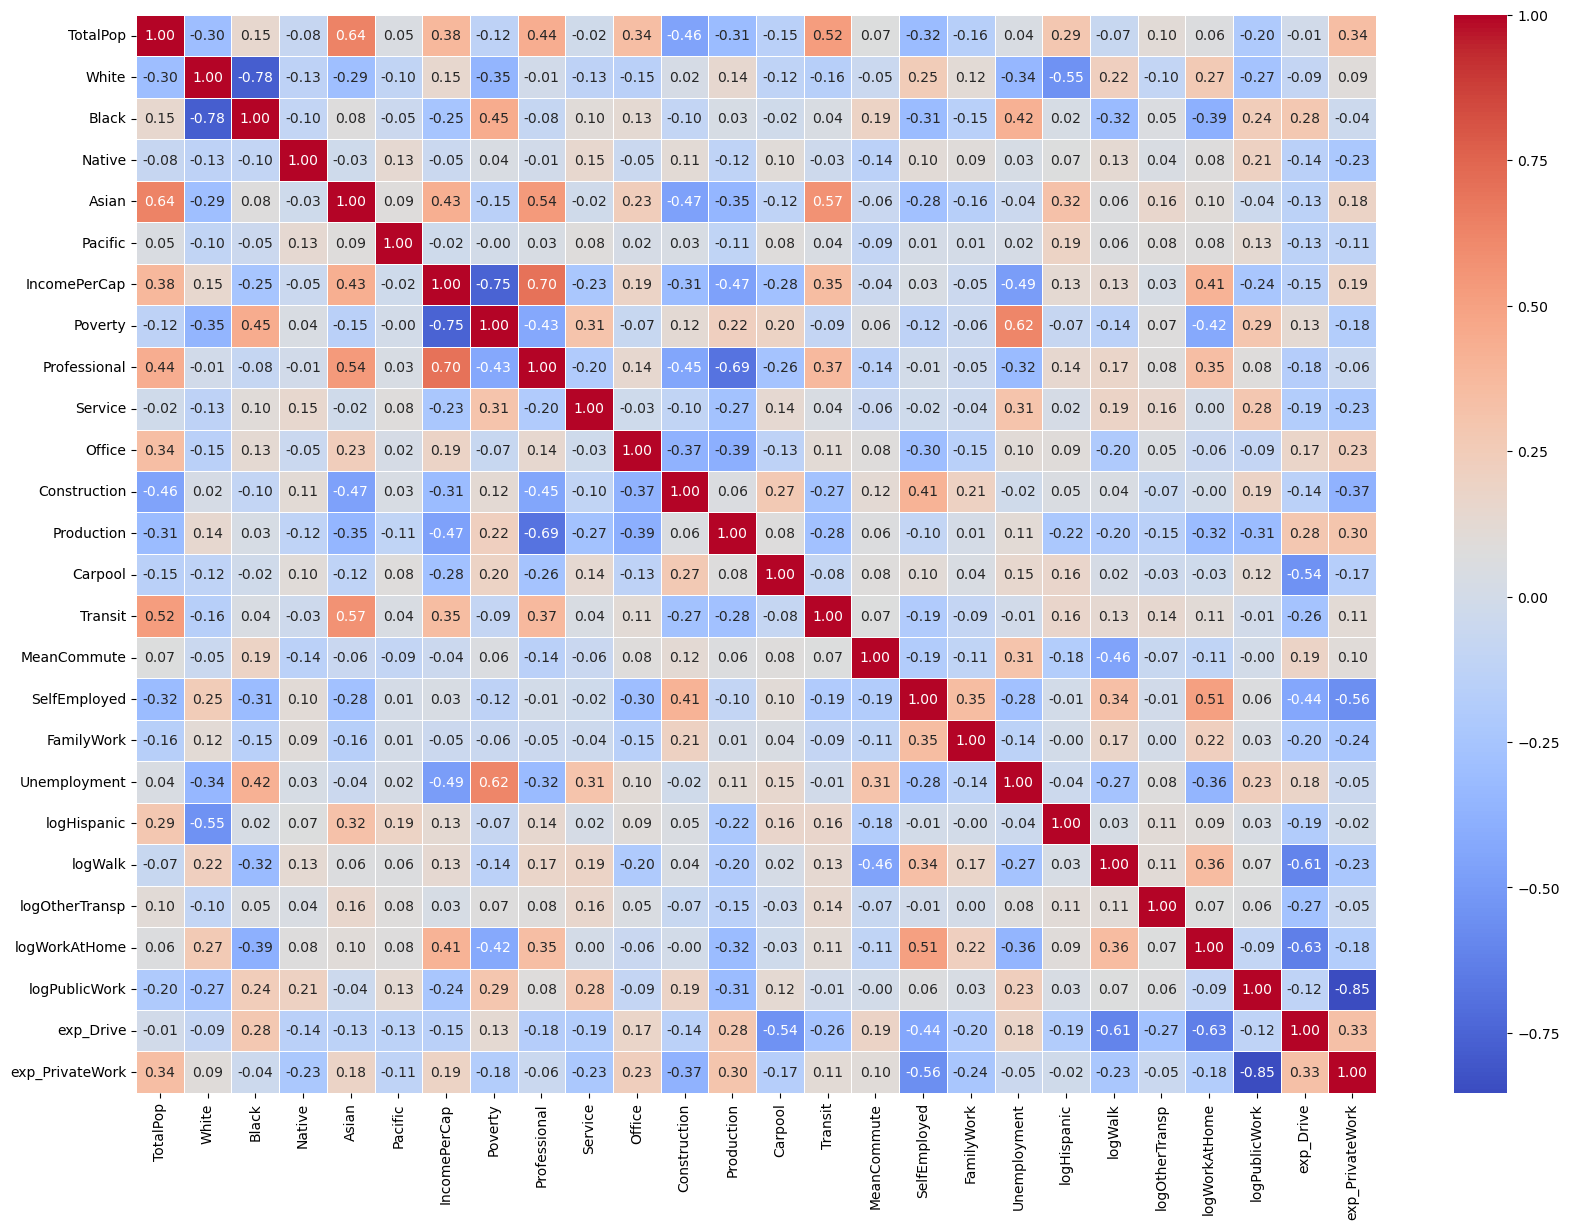

In [125]:
correlation_matrix = df.iloc[:,3:].corr()

plt.figure(figsize=(20, 14))
heatmap = sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm',fmt=".2f", linewidths=0.5)

Przetransformowane atrybuty `logPublicWork` i `exp_PrivateWork` mają wysoką korelację, więc należy jeden z nich usunąć. Usuniemy ten z mniejszą korelacją z atrybutem decyzyjnym, czyli `exp_PrivateWork`

In [126]:
df = df.drop(columns = ['exp_PrivateWork'], inplace=True)

In [127]:
df

In [128]:
df.columns.to_list()

AttributeError: 'NoneType' object has no attribute 'columns'

In [104]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Lasso, ElasticNet, Ridge
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.linear_model import LogisticRegressionCV
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import (
    RocCurveDisplay,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

### Dobór cech dla modelu regresji liniowej przy użyciu metody zachłannej

In [105]:
from scripts.greedy_features import find_best_features

features = df.columns[3:]
find_best_features(df[features], 'IncomePerCap')

['Poverty'] 10218987.616236247

['Poverty', 'Professional'] 6181474.142286185

['Poverty', 'Professional', 'Transit'] 5750391.221591769

['Poverty', 'Professional', 'Transit', 'logPublicWork'] 5431070.075653491

['Poverty', 'Professional', 'Transit', 'logPublicWork', 'Production'] 5262537.830830058

['Poverty', 'Professional', 'Transit', 'logPublicWork', 'Production', 'Black'] 5193452.5677159475

['Poverty', 'Professional', 'Transit', 'logPublicWork', 'Production', 'Black', 'Asian'] 5150382.073154089

['Poverty', 'Professional', 'Transit', 'logPublicWork', 'Production', 'Black', 'Asian', 'Carpool'] 5106792.608413753

['Poverty', 'Professional', 'Transit', 'logPublicWork', 'Production', 'Black', 'Asian', 'Carpool', 'Pacific'] 5091916.9282371225

['Poverty', 'Professional', 'Transit', 'logPublicWork', 'Production', 'Black', 'Asian', 'Carpool', 'Pacific', 'FamilyWork'] 5083342.745717746

['Poverty', 'Professional', 'Transit', 'logPublicWork', 'Production', 'Black', 'Asian', 'Carpool', 'Pa

Użycie jedynie przetransformowanych atrybutów, zamiast ich zwykłych wersji

In [ ]:
from scripts.greedy_features import find_best_features

features = df.columns[3:]
left_skewed_list = left_skewed.tolist()
right_skewed_list = right_skewed.tolist()
filtered_features = [item for item in features if item not in left_skewed_list]
filtered_features2 = [item for item in filtered_features if item not in right_skewed_list]
find_best_features(df[filtered_features2], 'IncomePerCap')

['Poverty'] 10218987.616236247

['Poverty', 'Professional'] 6181474.142286185

['Poverty', 'Professional', 'logPublicWork'] 5817544.96750396

['Poverty', 'Professional', 'logPublicWork', 'Production'] 5607555.006579174

['Poverty', 'Professional', 'logPublicWork', 'Production', 'MeanCommute'] 5563120.745266628

['Poverty', 'Professional', 'logPublicWork', 'Production', 'MeanCommute', 'Carpool'] 5519550.068943863

['Poverty', 'Professional', 'logPublicWork', 'Production', 'MeanCommute', 'Carpool', 'exp_Drive'] 5489733.42959165

['Poverty', 'Professional', 'logPublicWork', 'Production', 'MeanCommute', 'Carpool', 'exp_Drive', 'logWalk'] 5466953.912533918

['Poverty', 'Professional', 'logPublicWork', 'Production', 'MeanCommute', 'Carpool', 'exp_Drive', 'logWalk', 'logWorkAtHome'] 5420773.388085706

['Poverty', 'Professional', 'logPublicWork', 'Production', 'MeanCommute', 'Carpool', 'exp_Drive', 'logWalk', 'logWorkAtHome', 'Construction'] 5411373.538511259

['Poverty', 'Professional', 'logP

Weryfikacja, czy skalowanie, lub standaryzacja zmiennych zmienia coś 

In [107]:
from sklearn.preprocessing import StandardScaler

std_dev_target = df['IncomePerCap'].std()

df_stantard = df[:]
scaler = StandardScaler()
columns_to_scale = df.columns[3:]
df_stantard[columns_to_scale] = scaler.fit_transform(df_stantard[columns_to_scale])

find_best_features(df_stantard[features], 'IncomePerCap', is_standarized=True, std_dev=std_dev_target)

['Poverty'] 0.43662735635206334

['Poverty', 'Professional'] 0.26411625245702414

['Poverty', 'Professional', 'Transit'] 0.2456973441365684

['Poverty', 'Professional', 'Transit', 'logPublicWork'] 0.23205368852073996

['Poverty', 'Professional', 'Transit', 'logPublicWork', 'Production'] 0.22485280020569606

['Poverty', 'Professional', 'Transit', 'logPublicWork', 'Production', 'Black'] 0.22190098962237795

['Poverty', 'Professional', 'Transit', 'logPublicWork', 'Production', 'Black', 'Asian'] 0.22006071376692643

['Poverty', 'Professional', 'Transit', 'logPublicWork', 'Production', 'Black', 'Asian', 'Carpool'] 0.21819826383850732

['Poverty', 'Professional', 'Transit', 'logPublicWork', 'Production', 'Black', 'Asian', 'Carpool', 'Pacific'] 0.21756266967268778

['Poverty', 'Professional', 'Transit', 'logPublicWork', 'Production', 'Black', 'Asian', 'Carpool', 'Pacific', 'FamilyWork'] 0.21719632001194783

['Poverty', 'Professional', 'Transit', 'logPublicWork', 'Production', 'Black', 'Asian'

In [108]:
from sklearn.preprocessing import MinMaxScaler

min_target = df['IncomePerCap'].min()
max_target = df['IncomePerCap'].max()
range_target = max_target - min_target

df_normalized = df[:]
scaler = MinMaxScaler()
columns_to_scale = df.columns[3:]
df_normalized[columns_to_scale] = scaler.fit_transform(df_normalized[columns_to_scale])

find_best_features(df_normalized[features], 'IncomePerCap', is_normalized=True, range_minmax=range_target)

['Poverty'] 0.009372463008337951

['Poverty', 'Professional'] 0.005669410700089793

['Poverty', 'Professional', 'Transit'] 0.005274037999831763

['Poverty', 'Professional', 'Transit', 'logPublicWork'] 0.004981168907463794

['Poverty', 'Professional', 'Transit', 'logPublicWork', 'Production'] 0.004826597604548217

['Poverty', 'Professional', 'Transit', 'logPublicWork', 'Production', 'Black'] 0.004763235254257318

['Poverty', 'Professional', 'Transit', 'logPublicWork', 'Production', 'Black', 'Asian'] 0.004723732650653961

['Poverty', 'Professional', 'Transit', 'logPublicWork', 'Production', 'Black', 'Asian', 'Carpool'] 0.00468375406753258

['Poverty', 'Professional', 'Transit', 'logPublicWork', 'Production', 'Black', 'Asian', 'Carpool', 'Pacific'] 0.004670110664935844

['Poverty', 'Professional', 'Transit', 'logPublicWork', 'Production', 'Black', 'Asian', 'Carpool', 'Pacific', 'FamilyWork'] 0.004662246753997946

['Poverty', 'Professional', 'Transit', 'logPublicWork', 'Production', 'Black

In [109]:
y = df['IncomePerCap']
x = df.drop(columns=['IncomePerCap', 'Unnamed: 0', 'County', 'State'])
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
features = x_train.columns.values
features

array(['TotalPop', 'White', 'Black', 'Native', 'Asian', 'Pacific',
       'Poverty', 'Professional', 'Service', 'Office', 'Construction',
       'Production', 'Carpool', 'Transit', 'MeanCommute', 'SelfEmployed',
       'FamilyWork', 'Unemployment', 'logHispanic', 'logWalk',
       'logOtherTransp', 'logWorkAtHome', 'logPublicWork', 'exp_Drive',
       'exp_PrivateWork'], dtype=object)

In [110]:
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

In [111]:
regresor = LinearRegression()
regresor.fit(x_train, y_train)
y_pred_train = regresor.predict(x_train)
y_pred_test = regresor.predict(x_test)
print('Multiple Linear Regression')
e_train= mean_squared_error(y_train, y_pred_train)
e_test = mean_squared_error(y_test, y_pred_test)
print('Mean Squared Error for train:', e_train)
print('Mean Squared Error for test:', e_test)
r2_train = r2_score(y_train, y_pred_train)
r2_test = r2_score(y_test, y_pred_test)
print('R2 Score for train:', r2_train)
print('R2 Score for test:', r2_test)



Multiple Linear Regression
Mean Squared Error for train: 4878238.44472029
Mean Squared Error for test: 4853600.904826598
R2 Score for train: 0.7905241018201669
R2 Score for test: 0.7966111658191737


/tmp/ipykernel_8945/3185005997.py:4: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "k--" (-> color='k'). The keyword argument will take precedence.
  plt.plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], 'k--', color="red", label="Ideal Fit")


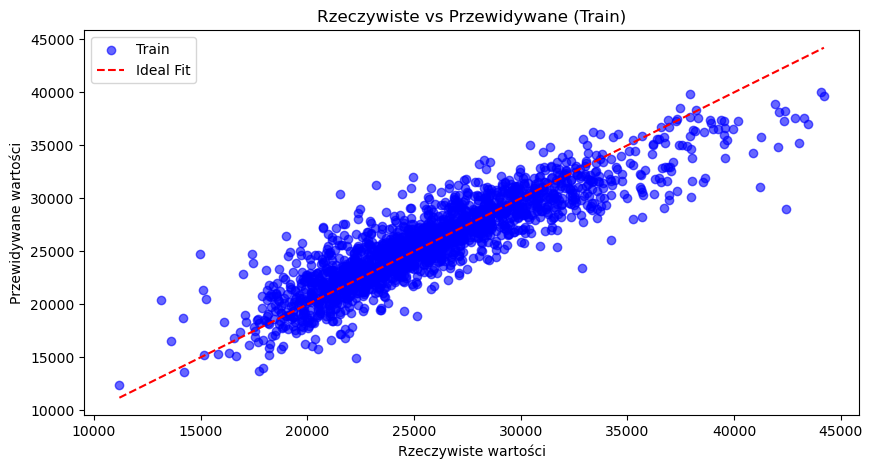

/tmp/ipykernel_8945/3185005997.py:14: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "k--" (-> color='k'). The keyword argument will take precedence.
  plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', color="red", label="Ideal Fit")


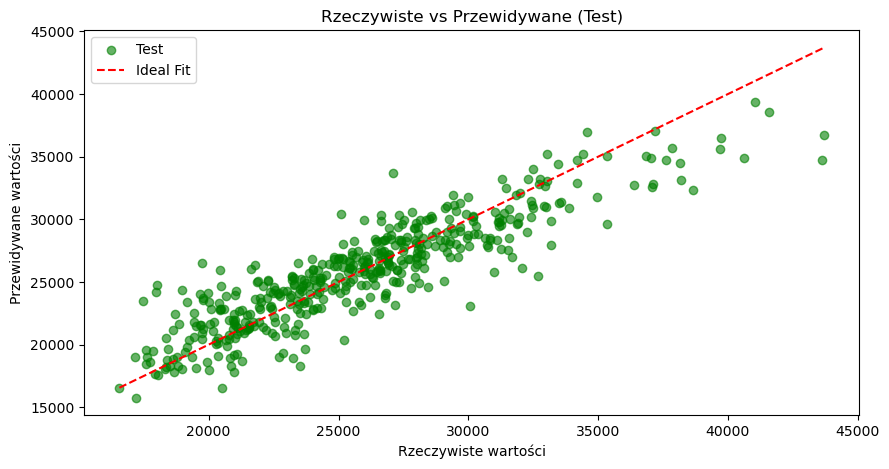

In [112]:
# Dla zbioru treningowego
plt.figure(figsize=(10, 5))
plt.scatter(y_train, y_pred_train, alpha=0.6, color="blue", label="Train")
plt.plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], 'k--', color="red", label="Ideal Fit")
plt.xlabel("Rzeczywiste wartości")
plt.ylabel("Przewidywane wartości")
plt.title("Rzeczywiste vs Przewidywane (Train)")
plt.legend()
plt.show()

# Dla zbioru testowego
plt.figure(figsize=(10, 5))
plt.scatter(y_test, y_pred_test, alpha=0.6, color="green", label="Test")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', color="red", label="Ideal Fit")
plt.xlabel("Rzeczywiste wartości")
plt.ylabel("Przewidywane wartości")
plt.title("Rzeczywiste vs Przewidywane (Test)")
plt.legend()
plt.show()

In [113]:

intercept = regresor.intercept_
print("Wyraz wolny (Intercept):", intercept)

coefficients = regresor.coef_
for idx, coef in enumerate(coefficients):
    print(f"{idx} współczynnik: {coef}")


Wyraz wolny (Intercept): 25913.005373455126
0 współczynnik: 20.546542431597807
1 współczynnik: 190.57508853780018
2 współczynnik: 357.7407230400214
3 współczynnik: 149.40297198710317
4 współczynnik: 356.3010240135326
5 współczynnik: -175.03182034520006
6 współczynnik: -2438.4213145457907
7 współczynnik: -3852.5407142018844
8 współczynnik: -2794.9604167716534
9 współczynnik: -2570.241799902211
10 współczynnik: -3412.7758069969004
11 współczynnik: -5849.868203687751
12 współczynnik: -299.13667404877054
13 współczynnik: 463.3087674710338
14 współczynnik: 208.75601500822313
15 współczynnik: 189.56718930247163
16 współczynnik: -192.42665001849662
17 współczynnik: -210.76829170957313
18 współczynnik: 111.90146014360862
19 współczynnik: -91.7827708987366
20 współczynnik: 42.16371144729571
21 współczynnik: 30.3699951731316
22 współczynnik: -832.2596135706824
23 współczynnik: -68.1825011506677
24 współczynnik: -122.04725668353257


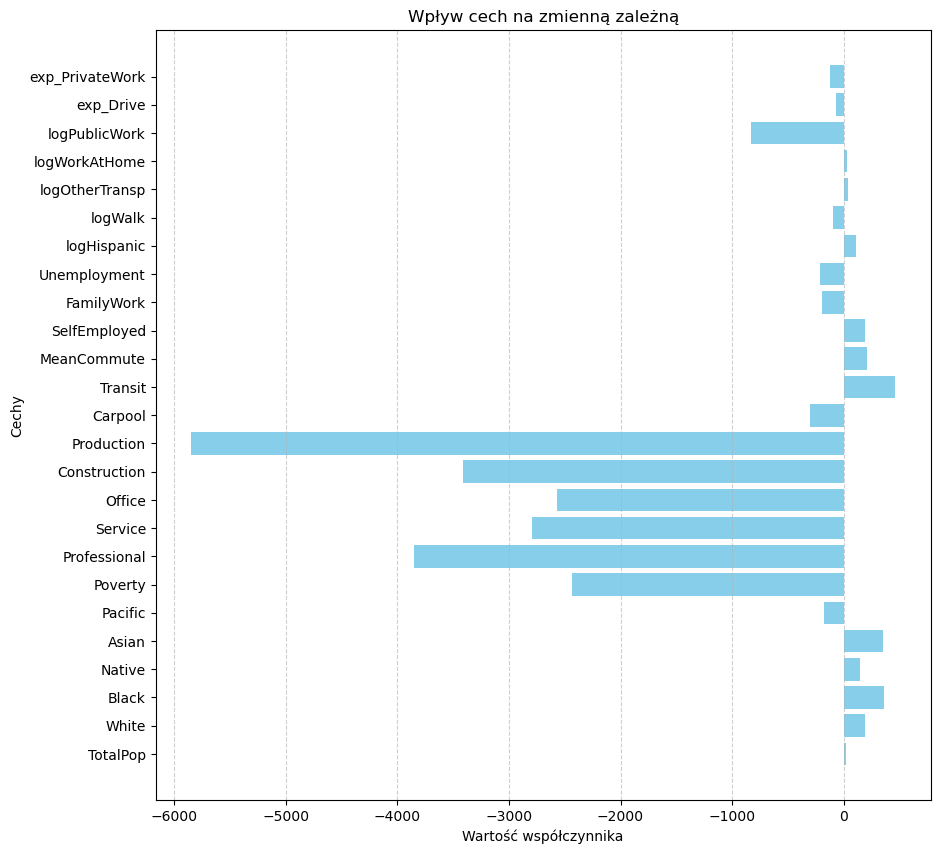

In [114]:
feature_names = x.columns 
coefficients = regresor.coef_


plt.figure(figsize=(10, 10))
plt.barh(feature_names, coefficients, color='skyblue')
plt.xlabel("Wartość współczynnika")
plt.ylabel("Cechy")
plt.title("Wpływ cech na zmienną zależną")
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.show()

In [115]:
poly_regresor = PolynomialFeatures(degree=4)
x_poly = poly_regresor.fit_transform(x_train)

moznaby dla roznych stopni wielomianu, ale idk czy jest sens sie nad tym tak rozwodzic czy lepiej skupic sie na innych modelach